In [395]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import torch.optim as optim
import matplotlib.pyplot as plt

torch.manual_seed(42) #for reproduceability, hopefully it actually works

Create Functions that are needed (pre-trianing)

In [329]:
#regular x,t normalization
def normalize(x,xt_Train):
    numerator = 2 * (x - xt_Train.min())
    denominator = xt_Train.max() - xt_Train.min()
    return (numerator / denominator) - 1

def slope_value(x_raw):
    x_raw = x_raw.detach().cpu().numpy()
    slope = pd.read_csv("slope_field.csv",usecols=['slope','length (m)'])
    bedslope_x = slope['length (m)'].values
    bedslope_S0 = slope['slope'].values

    interpolate = np.interp(x_raw,bedslope_x,bedslope_S0)
    return torch.tensor(interpolate,dtype=torch.float32).view(-1,1)

def grad_norm(loss, pinn_model):
    grads = torch.autograd.grad(
        loss,
        pinn_model.parameters(),
        retain_graph=True,
        create_graph=True
    )
    return torch.sqrt(sum((g**2).sum() for g in grads))

Pull Training Data:

In [92]:
station1_xt = pd.read_csv("station_1.csv",usecols=['x (m)','t (days)']) #(x,t)
station1_Qhb = pd.read_csv("station_1.csv",usecols=['Width (m)','Discharge (cms)','Depth (m)']) #(Q,h,b)

station2_xt = pd.read_csv("station_2.csv",usecols=['x (m)','t (days)'])
station2_Qhb = pd.read_csv("station_2.csv",usecols=['Width (m)','Discharge (cms)','Depth (m)']) #(Q,h,b)

station3_xt = pd.read_csv("station_3.csv",usecols=['x (m)','t (days)'])
station3_Qhb = pd.read_csv("station_3.csv",usecols=['Width (m)','Discharge (cms)','Depth (m)']) #(Q,h,b)

station4_xt = pd.read_csv("station_4.csv",usecols=['x (m)','t (days)'])
station4_Qhb = pd.read_csv("station_4.csv",usecols=['Width (m)','Discharge (cms)','Depth (m)']) #(Q,h,b)

x_t_raw = pd.concat([station1_xt,station2_xt,station3_xt,station4_xt])
x_t_Train=x_t_raw.reindex(columns=['x (m)','t (days)'])

Q_h_b_raw = pd.concat([station1_Qhb,station2_Qhb,station3_Qhb,station4_Qhb],join='outer',ignore_index=True)
Q_h_b_Train = Q_h_b_raw.reindex(columns=['Discharge (cms)','Depth (m)','Width (m)'])

#confirm the concats are the same size/no data was lost
print(len(x_t_Train))
print(len(Q_h_b_Train))

273
273


Make full training sets that will be fed into the training loop. We will need to separate the t=0 initial case and the x=0 boundary case (note that the dwonstream is free flow) from all observation data for loss calculations: 

In [365]:
#initial case 
xt_ic = x_t_Train[(x_t_Train['t (days)']  - 0).abs() < 1e-6] 
Qhb_ic = Q_h_b_Train.iloc[xt_ic.index]
#confirm sizes
print(len(xt_ic))
print(len(Qhb_ic))

#boundaries x=0 and x=L
xt_bc = x_t_Train[
    ((x_t_Train['x (m)'] - x_t_Train['x (m)'].min()).abs() < 1e-6) #x=0
]
Qhb_bc = Q_h_b_Train.iloc[xt_bc.index]
#confirm sizes
print(len(xt_bc))
print(len(Qhb_bc))

#Observation data
xt_obs = x_t_Train[
    (x_t_Train['t (days)'] != 0) &
    (x_t_Train['x (m)'] != x_t_Train['x (m)'].min()) 
]
Qhb_obs  = Q_h_b_Train.iloc[xt_obs.index]
#confirm sizes
print(len(xt_obs))
print(len(Qhb_obs))

#confirm no rows were dropped (note that ic overlapped with bc so it isn't included)
print(len(xt_bc)+len(xt_obs))
print(len(Qhb_bc)+len(Qhb_obs))

1
1
50
50
223
223
273
273


Now lets normalize our (x,t) data sets using the global (x_t_Train) reference point. In addition, lets create true tensor sets for Q, h, and b in all conditions for training comparisons:

In [ ]:
xt_ic_norm = torch.tensor(normalize(xt_ic,x_t_Train).values,dtype=torch.float32)
xt_bc_norm = torch.tensor(normalize(xt_bc,x_t_Train).values,dtype=torch.float32)
xt_obs_norm = torch.tensor(normalize(xt_obs,x_t_Train).values,dtype=torch.float32).requires_grad_(True)#for the pde
#xt_norm = torch.tensor(normalize(x_t_Train,x_t_Train).values,dtype=torch.float32).requires_grad_(True) #for the pde, only when testing not total

Qhb_bc = torch.tensor(Qhb_bc.values,dtype=torch.float32).requires_grad_(True)
Q_b = Qhb_bc[:, 0:1]
h_b = Qhb_bc[:, 1:2]
b_b = Qhb_bc[:, 2:3]

Qhb_ic = torch.tensor(Qhb_ic.values,dtype=torch.float32).requires_grad_(True)
Q_i = Qhb_ic[:, 0:1]
h_i = Qhb_ic[:, 1:2]
b_i = Qhb_ic[:, 2:3]

Qhb_true = torch.tensor(Qhb_obs.values,dtype=torch.float32).requires_grad_(True)
Q_true = Qhb_true[:, 0:1]
h_true = Qhb_true[:, 1:2]
b_true = Qhb_true[:, 2:3]

As recommended in paper, activation will be tanh. Different hidden layer sizes in training will be tested, while the final values included will be what I considered "best" in the code block. 

In [515]:
class SVE_PINN(nn.Module):
    def __init__(self):
        super().__init__()

        #define the model
        # note that there will be a record of hidden sizes in the future, changed here!

        self.model = nn.Sequential(
            nn.Linear(2,64), #x,t NORMALIZED!
            nn.Tanh(),
            nn.Linear(64,64),
            nn.Tanh(),
            nn.Linear(64,64),
            nn.Tanh(),
            nn.Linear(64,64),
            nn.Tanh(),
            nn.Linear(64,3),#Q,h,b
        )
    def forward(self, x_t_norm):
        output = self.model(x_t_norm)
        Q = output[:, 0:1]
        h = output[:, 1:2]
        b = output[:, 2:3]

        return Q, h, b #returning each prediction individually here
    
pinn_model = SVE_PINN()

This is the network for estimating Mannings n. Based upon the Chow table (1959), and the fact that the river is mostly wider than 100ft, the restricted range of Mannings n is Table D-3.a = 0.025 - 0.06. Following the same framework as the main paper reference, we will use tanh activation, and one order less of hidden layers. The mannings n value will be returned for visual inspection, but since it is a regularization method there is no direct loss calculated (basically, no training values since these are estimates anyway). 

In addition, the blind training will treat Mannings as a function of irregularity with x. As shown in the USGS guide for selecting roughness coefficients, Mannings n is based on channel irregularities in flow and channel properties as well as x. So, we will train n on inputs of x, S_0, and Q.

This also isn't being actively looked at for accuracy, so the hidden sizes are going to remain the same.

In [516]:
class Roughness(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(3,64), #x,S_0,Q (predicted)
            nn.Tanh(),
            nn.Linear(64,64),
            nn.Tanh(),
            nn.Linear(64,1) #n value
        )
        self.min = 0.025
        self.max = 0.06

    def forward(self,x_norm,S_0,Q):
        n_model = self.model(torch.cat([x_norm,S_0,Q],dim=1))
        #fit to 0-1:
        n_sigmoid = torch.sigmoid(n_model)
        #scale to actual/known range of 0.025-0.06
        n = self.min + (self.max - self.min)*n_sigmoid
        return n
mannings = Roughness()

Next code block is for the PDE. The formulas are derived from the SVE formulas, as shown in LaTeX below: 

<u> Mass </u>

Original form: 
$$\frac{dA}{dt} + \frac{dQ}{dx} = q \\[2ex]$$
Dynamic Width Solution:
$$A(x,t) = b(x,t)*h(x,t) \\[2ex]
\frac{dA}{dt} = \frac{d(b(x,t)*h(x,t))}{dt} \\[2ex]
\frac{dA}{dt} = b \frac{dh}{dt}+h \frac{db}{dt} \\[2ex]
\boxed{b \frac{dh}{dt}+h \frac{db}{dt} + \frac{dQ}{dx} = 0}$$

<u> Momentum </u>

Original form: 
$$\frac{dQ}{dt} + \frac{d}{dx}(\frac{\alpha Q^2}{A} + gI_1) = gI_2 + gA(S_0-S_f)\\[2ex]
\text{where:} I_1 = \int_{0}^{H} b (h-z) \,dz \\[2ex]
I_2 = \int_{0}^{H} \frac{db}{dx}(h-z) \,dz \\[2ex]$$
Dynamic Width Solution:

Note that b doesn't vary with z:
$$I_1 = \int_{0}^{H} b (h-z) \,dz \\[2ex]
I_1 = b \int_{0}^{H} hdz-zdz \\[2ex]
\left.I_1 = b(hz - 0.5 z^2)\right|_0^H\\[2ex]
I_1 = b (h^2 - 0.5h^2) = b(0.5h^2)\\[2ex]\\[2ex]
\text{   }\\[2ex]
I_2 = \int_{0}^{H} \frac{db}{dx}(h-z) \,dz \\[2ex]
I_2 = \frac{db}{dx}\int_{0}^{H} (h-z) \,dz \\[2ex]
I_2 = \frac{db}{dx} (0.5h^2)
$$

Sub back in and let alpha be 1:

$$\frac{dQ}{dt} + \frac{d}{dx}(\frac{Q^2}{bh} + 0.5g(bh^2)) = g(\frac{db}{dx} (0.5h^2)) + gA(S_0-S_f)\\[2ex]
\frac{dQ}{dt} + \frac{d}{dx} \left[\frac{Q^2}{bh} + \frac{g b h^2}{2}\right]-\frac{db}{dx} \cdot \frac{g h^2}{2}-g b h S_0+g b h S_f = 0\\[2ex]
$$

Because now the width flux is accounted fro with d/dx on the left, we can remove the term on the right (meaning $I_2$ is accounted for already so only the slopes are remaining terms).

Solving just the d/dx term: 
$$\frac{d}{dx} \left[\frac{Q^2}{bh} + \frac{g b h^2}{2}\right]\\[2ex]
\text{first term: }  \frac{d}{dx}(\frac{Q^2}{bh})\\[2ex]
\frac{2Qbh\cdot\frac{dQ}{dx} - Q^2(h\frac{db}{dx} + b\frac{dh}{dx})}{b^2h^2}\\[2ex]\text{ }\\[2ex]
\text{second term: }  \frac{d}{dx}(\frac{g b h^2}{2})\\[2ex]
0.5gh^2 \frac{db}{dx} + ghb\frac{dh}{dx}$$

Therefore: 
$$\boxed{\frac{dQ}{dt} + \frac{2Qbh\cdot\frac{dQ}{dx} - Q^2(h\frac{db}{dx} + b\frac{dh}{dx})}{b^2h^2} + 0.5gh^2 \frac{db}{dx} + ghb\frac{dh}{dx}-g b h S_0+g b h S_f = 0}$$




In [486]:
def saint_venant_pde(x_t_Train,xt_norm,mannings,pinn_model):
    #pull each input individually for pde
    x_phys = xt_norm[:, 0:1]

    #Rescale to nondimensionalize (aka make x and t both matter to pde)
    x_nd = x_t_Train['x (m)'].max() - x_t_Train['x (m)'].min()
    t_nd = x_t_Train['t (days)'].max() - x_t_Train['t (days)'].min()
    g_nd = 9.8 * (t_nd**2 / x_nd)

    Q_model, h_model, b_model = pinn_model(xt_norm)
    #prevent negatives:
    Q = F.softplus(Q_model) + 1e-6
    h = F.softplus(h_model) + 1e-6 
    b = F.softplus(b_model) + 1e-6
    S_0 = slope_value(x_phys)#grabbing before nondimensionalizing
    n = mannings(x_phys,S_0,Q) #grabbing before nondimensionalizing

    #_____________________________________________________________
    #---Derivatives---
    d_dx = 2 / (x_t_Train['x (m)'].max() - x_t_Train['x (m)'].min())
    d_dt = 2 / (x_t_Train['t (days)'].max() - x_t_Train['t (days)'].min())
    #with respect to time and space (derivative of normalization)

    Q_x = torch.autograd.grad(Q, xt_norm, torch.ones_like(Q), create_graph=True)[0][:,0:1]
    Q_x = Q_x*d_dx
    Q_t = torch.autograd.grad(Q, xt_norm, torch.ones_like(Q), create_graph=True)[0][:,1:2]
    Q_t = Q_t *d_dt

    h_x = torch.autograd.grad(h, xt_norm, torch.ones_like(h), create_graph=True)[0][:,0:1]
    h_x = h_x*d_dx
    h_t = torch.autograd.grad(h, xt_norm, torch.ones_like(h), create_graph=True)[0][:,1:2]
    h_t = h_t *d_dt

    b_x = torch.autograd.grad(b, xt_norm, torch.ones_like(b), create_graph=True)[0][:,0:1]
    b_x = b_x*d_dx
    b_t = torch.autograd.grad(b, xt_norm, torch.ones_like(b), create_graph=True)[0][:,1:2]
    b_t = b_t *d_dt

    #_____________________________________________________________
    #Mass conservation
    
    mass = (b * h_t) + (h * b_t) + Q_x
    
    #_____________________________________________________________
    #Momentum conservation 
 
    R = (b*h)/(b+(2*h)+1e-6)
    S_f = ((n*Q)/(b*h*(R**(2/3))+ 1e-8))**2

    momentum = (Q_t + ((2*Q*b*h*Q_x) - ((Q**2)*(h*b_x + b*h_x)))/((b**2)*(h**2)) +
                (0.5*g_nd*(h**2)*b_x) + (g_nd*h*b*h_x) - (g_nd*b*h*S_0) + (g_nd*b*h*S_f))

    return mass, momentum

Now we can officially train! the loss function, optimizer, and initilaized weights are all defined here as well, before the training loop.

Because of this PINN structure, we will have physics, initial, boundary, and data losses, which are summed to be the total loss. We want the losses to be updated accurately as well. 

In [517]:
#extra initial parameters
lr=0.005
lamda=5
epochs = 5000 #may change if it doesn't feel sufficient, not something I am tracking though
optimize = optim.Adam(list(pinn_model.parameters()), lr=lr)
mse_loss = nn.MSELoss()
total_loss = []

Q_nd = Q_true.std().detach() + 1e-6
h_nd = h_true.std().detach() + 1e-6
b_nd = b_true.std().detach() + 1e-6

#training loop

for epoch in range(epochs):
    optimize.zero_grad()

    #Initial,Boundary, and Observation Condition Predictions
    Q_ic, h_ic, b_ic = pinn_model(xt_ic_norm)
    Q_bc, h_bc, b_bc = pinn_model(xt_bc_norm)
    Q_obs, h_obs, b_obs = pinn_model(xt_obs_norm)

    #Initial and Boundary loss

    L_i = mse_loss(Q_ic,Q_i) + mse_loss(h_ic,h_i) + mse_loss(b_ic,b_i)
    L_b = mse_loss(Q_bc,Q_b) + mse_loss(h_bc,h_b) + mse_loss(b_bc,b_b)

    #Data loss
    L_data = (((Q_obs - Q_true) / (Q_nd))**2).mean() + (((h_obs - h_true) / (h_nd))**2).mean() + (((b_obs - b_true) / (b_nd))**2).mean()

    #Physics loss
    #randomize midpoints to train physics on
    x = torch.rand(512, 1) #512 picked randomly
    t = torch.rand(512, 1)
    xt_phys = torch.cat([x,t], dim=1).requires_grad_(True)
    
    mass, momentum = saint_venant_pde(x_t_Train,xt_phys,mannings,pinn_model)
    L_physics = (mass**2).mean() + (momentum**2).mean()

    #____________________________________________________________________________________________
    L_total = L_i + L_b + L_data + lamda *L_physics

    loss = L_total

    #backpropogation 
    loss.backward()
    optimize.step()
    total_loss.append(loss.item())

    #extra logging to watch gradient
    if epoch % 250 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.6f}")

print(f"Final Loss: {total_loss[-1]:.6f}")

Epoch 0 | Loss: 68270.437500
Epoch 250 | Loss: 31552.083984
Epoch 500 | Loss: 26852.564453
Epoch 750 | Loss: 26569.238281
Epoch 1000 | Loss: 26562.335938
Epoch 1250 | Loss: 26562.062500
Epoch 1500 | Loss: 26562.093750
Epoch 1750 | Loss: 26561.972656
Epoch 2000 | Loss: 26561.863281
Epoch 2250 | Loss: 26033.490234
Epoch 2500 | Loss: 25834.095703
Epoch 2750 | Loss: 25681.402344
Epoch 3000 | Loss: 25561.906250
Epoch 3250 | Loss: 25467.800781
Epoch 3500 | Loss: 25393.937500
Epoch 3750 | Loss: 25336.595703
Epoch 4000 | Loss: 25292.847656
Epoch 4250 | Loss: 25260.212891
Epoch 4500 | Loss: 25236.619141
Epoch 4750 | Loss: 25220.226562
Final Loss: 25209.367188


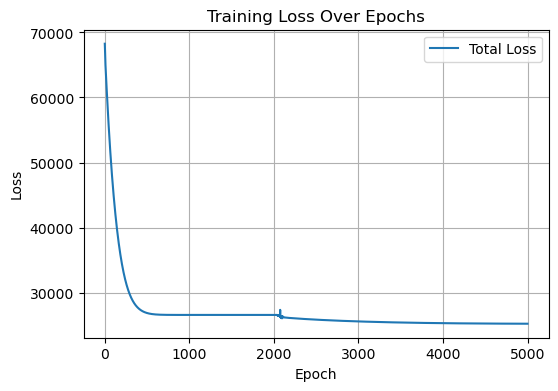

<Figure size 640x480 with 0 Axes>

In [561]:
plt.figure(figsize=(6,4))
plt.plot(total_loss, label="Total Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Over Epochs")
plt.legend()
plt.grid(True)
plt.show()
plt.savefig("loss.png")

Lets test it with our datasets, which includes both a new location and new times for our current x-values. We will show this through a heat map since the model predicts the flow as a map of (x,t)

In [557]:
test1_xt = pd.read_csv("test1.csv",usecols=['x (m)','t (days)']) #(x,t)
test1_Q = pd.read_csv("test1.csv",usecols=['Q (cms)']) #(Q)

test2_xt = pd.read_csv("test2.csv",usecols=['x (m)','t (days)']) #(x,t)
test2_Q = pd.read_csv("test2.csv",usecols=['Q (cms)']) #(Q)

test3_xt = pd.read_csv("test3.csv",usecols=['x (m)','t (days)']) #(x,t)
test3_Q = pd.read_csv("test3.csv",usecols=['Q (cms)']) #(Q)

test4_xt = pd.read_csv("test4.csv",usecols=['x (m)','t (days)']) #(x,t)
test4_Q = pd.read_csv("test4.csv",usecols=['Q (cms)']) #(Q)

# test5_xt = pd.read_csv("test5.csv",usecols=['x (m)','t (days)']) #(x,t)
# test5_Q = pd.read_csv("test5.csv",usecols=['Q (cms)']) #(Q)

test_xt = pd.concat([test1_xt,test2_xt,test3_xt,test4_xt,test5_xt])
test_xt=test_xt.reindex(columns=['x (m)','t (days)'])
test_xt_norm =torch.tensor(normalize(test_xt,x_t_Train).values,dtype=torch.float32)
test_Q = pd.concat([test1_Q,test2_Q,test3_Q,test4_Q,test5_Q])

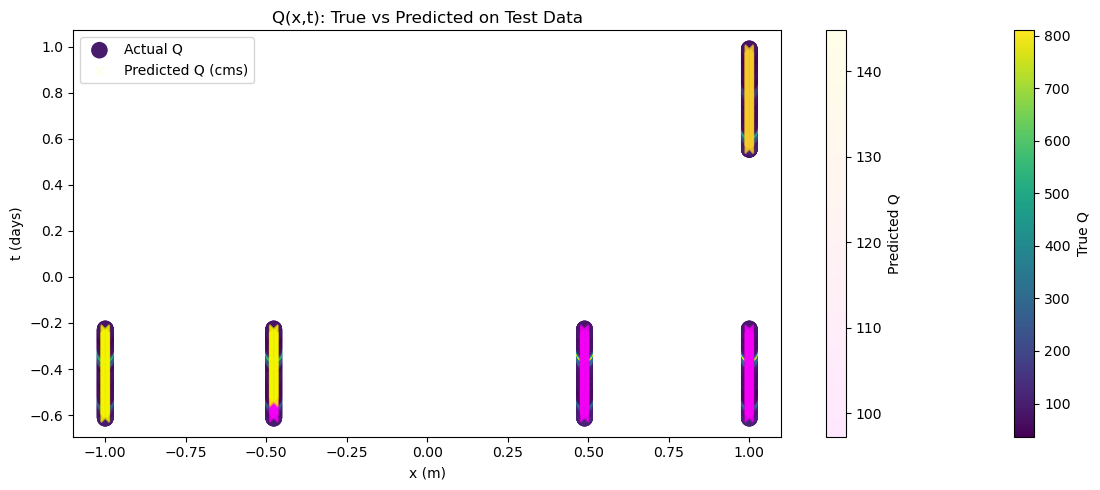

<Figure size 640x480 with 0 Axes>

In [562]:
#creating mesh-grid/heat map for Q(x,t)
pinn_model.eval()

with torch.no_grad():
    Q_predict, _, _ = pinn_model(test_xt_norm)
Q_predict = Q_predict.squeeze().cpu()
Q_test = torch.tensor(test_Q.values).float()
Q_test = Q_test.squeeze().cpu()
xt = test_xt_norm.cpu()

#building axes map so the true/predict are mapped to same reference
x = xt[:,0]
t = xt[:,1]

#make heat maps
fig, ax = plt.subplots(figsize=(12, 5))

true = plt.scatter(
    x, t,
    c=Q_test,
    cmap="viridis",
    marker="o",
    label="Actual Q",
    s = 120,
    alpha=1
)

predict = plt.scatter(
    x, t,
    c=Q_predict,
    cmap="spring",
    marker="x",
    s = 40,
    label="Predicted Q (cms)",
    alpha=0.09
    )

plt.xlabel("x (m)")
plt.ylabel("t (days)")
plt.title("Q(x,t): True vs Predicted on Test Data")

plt.colorbar(true, label="True Q")
plt.colorbar(predict, label="Predicted Q")

plt.legend()
plt.tight_layout()
plt.show()
plt.savefig("x_t_plot.png")

For better visuals, we wil also show Q with t at the 5 x values we have: 

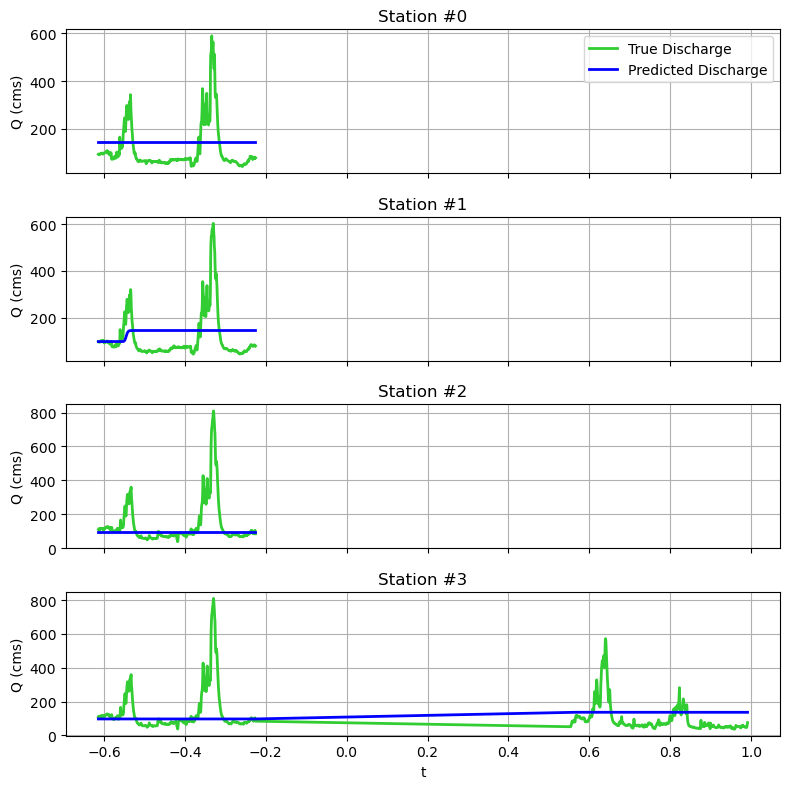

<Figure size 640x480 with 0 Axes>

In [563]:
x_stations = torch.unique(x)
fig, axes = plt.subplots(len(x_stations), 1, figsize=(8, 2*len(x_stations)), sharex=True) #one figure per USGS station

for i,station in enumerate(x_stations):
    #get data by specific x
    station_id = (x == station)
    t_i = t[station_id]
    Q_true_i = Q_test[station_id]
    Q_predict_i = Q_predict[station_id]

    #sort these sets by time
    time = torch.argsort(t_i)
    t_i = t_i[time]
    Q_true_i = Q_true_i[time]
    Q_predict_i = Q_predict_i[time]

    #plot the subfigure with time as the reference/x-axis
    axes[i].plot(t_i, Q_true_i, label="True Discharge", linewidth=2, color='limegreen')
    axes[i].plot(t_i, Q_predict_i, label="Predicted Discharge", linewidth=2,color='blue')
    axes[i].set_title(f"Station #{i}")
    axes[i].set_ylabel("Q (cms)")
    axes[i].grid()

    if i == 0:
            axes[i].legend()


axes[-1].set_xlabel("t")
plt.tight_layout()
plt.show()
plt.savefig("hydrograph_x.png")